    Global_youtube_creator_data
Part A: Data Understanding and Exploration

Import Libraries

Load Dataset

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

df = pd.read_csv("global_youtube_creator_data_large.csv")

In [24]:
df.head()

,timestamp,video_id,category,language,region,duration_sec,views,likes,comments,shares,sentiment_score,ads_enabled
0,14-09-2024 05:08,VID_589765,Vlogs,Japanese,PK,873,6826,396,34,31,-0.082,True
1,09-08-2025 12:23,VID_577279,Tech Reviews,Urdu,UK,2335,11371,402,26,19,-0.873,False
2,04-03-2024 14:39,VID_890301,Gaming,English,BR,1895,7509,730,45,25,-0.764,True
3,04-05-2025 11:05,VID_613444,Education,Urdu,PK,841,17361,1302,122,25,-0.788,True
4,22-09-2024 20:22,VID_602671,Gaming,Japanese,IN,1246,18494,756,63,42,0.521,False


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   timestamp        1000000 non-null  str    
 1   video_id         1000000 non-null  str    
 2   category         1000000 non-null  str    
 3   language         1000000 non-null  str    
 4   region           1000000 non-null  str    
 5   duration_sec     1000000 non-null  int64  
 6   views            1000000 non-null  int64  
 7   likes            1000000 non-null  int64  
 8   comments         1000000 non-null  int64  
 9   shares           1000000 non-null  int64  
 10  sentiment_score  1000000 non-null  float64
 11  ads_enabled      1000000 non-null  bool   
dtypes: bool(1), float64(1), int64(5), str(5)
memory usage: 84.9 MB


In [26]:
df.shape

(1000000, 12)

In [27]:
df.columns

Index(['timestamp', 'video_id', 'category', 'language', 'region',
       'duration_sec', 'views', 'likes', 'comments', 'shares',
       'sentiment_score', 'ads_enabled'],
      dtype='str')

In [28]:
df.dtypes

timestamp              str
video_id               str
category               str
language               str
region                 str
duration_sec         int64
views                int64
likes                int64
comments             int64
shares               int64
sentiment_score    float64
ads_enabled           bool
dtype: object

In [29]:
df.describe()

,duration_sec,views,likes,comments,shares,sentiment_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.00000,1000000.000000,1000000.000000
mean,1829.589053,10012.587052,550.139094,68.34110,29.536169,0.000547
std,1022.387019,9999.381263,662.291287,90.89229,34.185734,0.577070
min,60.000000,0.000000,0.000000,0.00000,0.000000,-1.000000
25%,943.000000,2885.000000,121.000000,13.00000,7.000000,-0.499000
50%,1830.000000,6943.000000,321.000000,37.00000,18.000000,0.001000
75%,2715.000000,13877.000000,727.000000,87.00000,40.000000,0.500000
max,3599.000000,147139.000000,11970.000000,1795.00000,718.000000,1.000000


Missing Values Check

In [30]:
df.isnull().sum()

timestamp          0
video_id           0
category           0
language           0
region             0
duration_sec       0
views              0
likes              0
comments           0
shares             0
sentiment_score    0
ads_enabled        0
dtype: int64

 Histogram Visualization

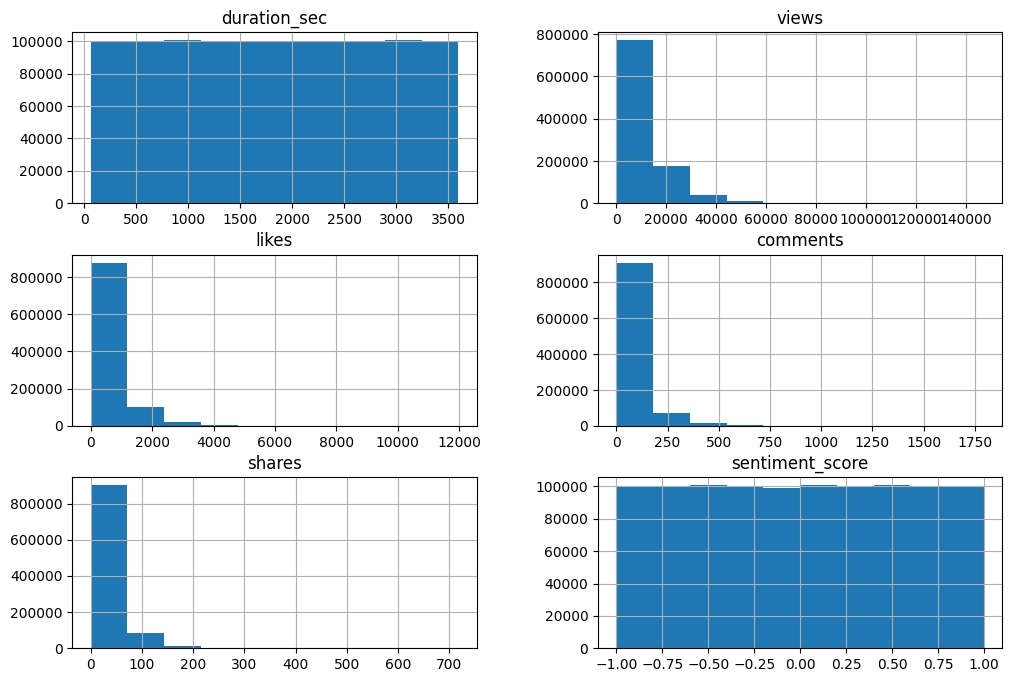

In [31]:
df.hist(figsize=(12,8))
plt.show()

Correlation Matrix

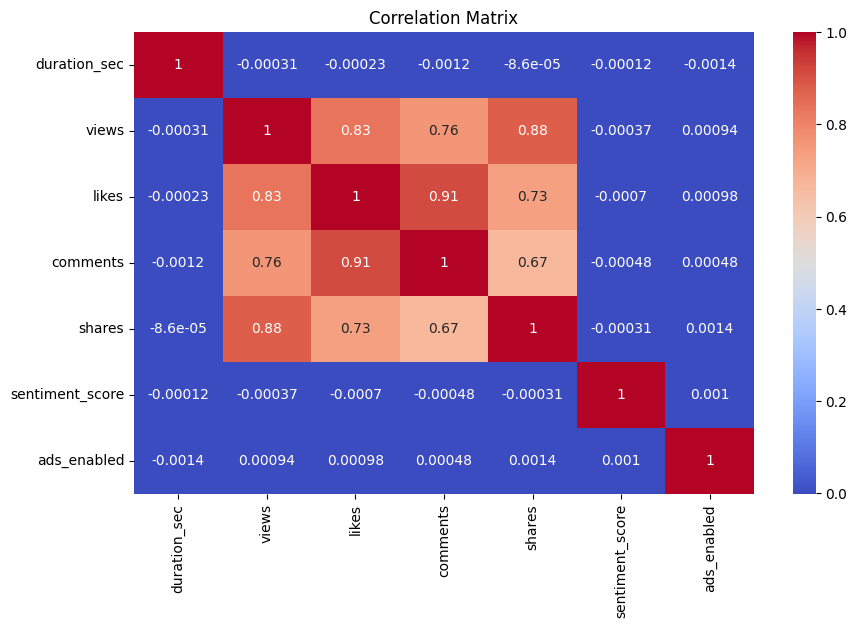

In [32]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Encode Categorical Data

In [46]:
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

C:\Users\Admin\AppData\Local\Temp\ipykernel_15896\3111725348.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


Feature Scaling

In [47]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

Train Test Split

In [48]:
X = df.drop(df.columns[-1], axis=1)
y = df[df.columns[-1]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (800000, 11)
Test Shape: (200000, 11)


Data Cleaning (Assignment Part B)

In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

,timestamp,video_id,category,language,region,duration_sec,views,likes,comments,shares,sentiment_score,ads_enabled
0,14-09-2024 05:08,VID_589765,Vlogs,Japanese,PK,873,6826,396,34,31,-0.082,True
1,09-08-2025 12:23,VID_577279,Tech Reviews,Urdu,UK,2335,11371,402,26,19,-0.873,False
2,04-03-2024 14:39,VID_890301,Gaming,English,BR,1895,7509,730,45,25,-0.764,True
3,04-05-2025 11:05,VID_613444,Education,Urdu,PK,841,17361,1302,122,25,-0.788,True
4,22-09-2024 20:22,VID_602671,Gaming,Japanese,IN,1246,18494,756,63,42,0.521,False
...,...,...,...,...,...,...,...,...,...,...,...,...
999995,25-06-2024 13:51,VID_383631,Tech Reviews,Urdu,IN,3052,9019,345,58,9,0.122,True
999996,25-05-2025 06:00,VID_415513,Gaming,Japanese,BR,3145,1831,104,12,2,0.043,False
999997,16-07-2025 23:45,VID_638447,Gaming,English,US,2269,17,1,0,0,-0.784,False
999998,07-01-2025 21:06,VID_177749,Education,Urdu,UK,1351,7355,555,54,34,0.978,True


Remove duplicates:

In [34]:
df.drop_duplicates(inplace=True)

Encode Categorical Data

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

C:\Users\Admin\AppData\Local\Temp\ipykernel_15896\1984379775.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object'):


Feature Scaling

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

PCA (Assignment Part C)

PCA Implementation

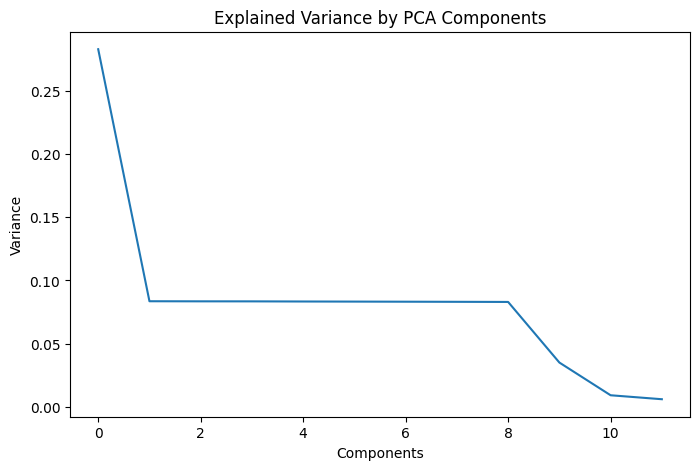

In [49]:
pca = PCA()

X_pca = pca.fit_transform(scaled_data)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(explained_variance)
plt.title("Explained Variance by PCA Components")
plt.xlabel("Components")
plt.ylabel("Variance")
plt.show()

 Reduce to 2 components

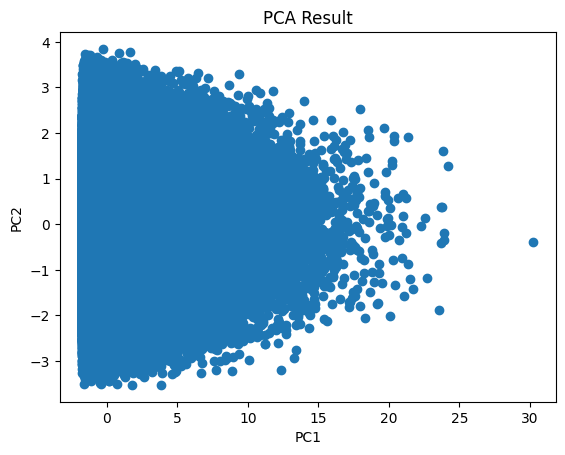

In [50]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_data)

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Result")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


LDA Implementation

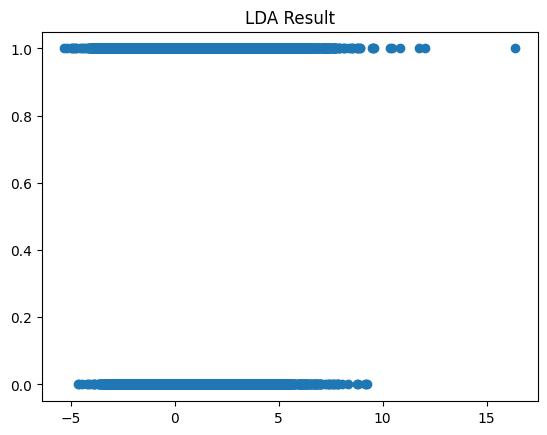

In [51]:
lda = LinearDiscriminantAnalysis(n_components=1)

try:
    X_lda = lda.fit_transform(X, y)

    plt.scatter(X_lda, y)
    plt.title("LDA Result")
    plt.show()

except:
    print("LDA cannot be applied if dataset has no proper class labels")

KPI / Analytics (Assignment Part D)

In [52]:
print("\nKey Performance Indicators")

print("Average Values:")
print(df.mean())

print("\nTop Correlated Features:")
corr = df.corr()
print(corr)


Key Performance Indicators
Average Values:
timestamp          322468.480484
video_id           301652.246547
category                2.500545
language                1.997942
region                  2.000087
duration_sec         1829.589053
views               10012.587052
likes                 550.139094
comments               68.341100
shares                 29.536169
sentiment_score         0.000547
ads_enabled             0.800188
dtype: float64

Top Correlated Features:
                 timestamp  video_id  category  language    region  \
timestamp         1.000000  0.000239 -0.000065 -0.001586  0.001703   
video_id          0.000239  1.000000 -0.000353  0.000115  0.001227   
category         -0.000065 -0.000353  1.000000 -0.000396  0.000843   
language         -0.001586  0.000115 -0.000396  1.000000 -0.000182   
region            0.001703  0.001227  0.000843 -0.000182  1.000000   
duration_sec     -0.000531 -0.000828  0.000481 -0.000689  0.000555   
views             0.000863 -0

Scatter Plot Example

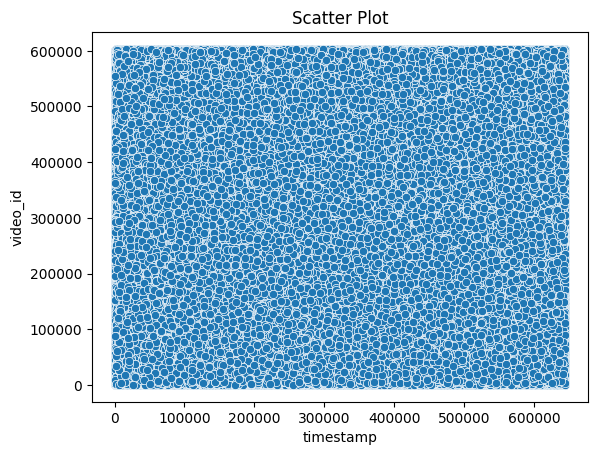


Analysis Completed Successfully


In [ ]:
sns.scatterplot(x=df.iloc[:,0], y=df.iloc[:,1])
plt.title("Scatter Plot")
plt.show()